In [1]:
# DS4400 HW 4
# Eunchae Hong
# Problem 3: AdaBoost Ensemble

import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc
)
import matplotlib.pyplot as plt

# load the spam database in
spam_data = pd.read_csv("spambase/spambase.data", header = None)

In [2]:
'''
    Part 1
    Use an existing package to train an AdaBoost ensemble with 10, 50, 100, and 500 base classifiers on the SPAMBASE dataset.
    Use a decision tree classifier as the base classification model. 
    Report accuracy, F1 score, and AUC on both the training and testing sets.
'''

# train test split on the data
X = spam_data.iloc[:, :-1].values
y = spam_data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 5)

T = [10, 50, 100, 500]

def adaboost(n_estimators):
    model = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 1), n_estimators = n_estimators, random_state = 5)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    y_prob_test  = model.predict_proba(X_test)[:, 1]
    y_prob_train = model.predict_proba(X_train)[:, 1]

    # training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_prob_train)

    # testing metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob_test)

    print("Training Metrics for T =", n_estimators)
    print("-" * 20)
    print(f"Accuracy: {round(train_accuracy, 3)}")
    print(f"F1 Score: {round(train_f1, 3)}\nAUC: {round(train_auc, 3)}")

    print("Testing Metrics for T =", n_estimators)
    print("-" * 20)
    print(f"Accuracy: {round(test_accuracy, 3)}")
    print(f"F1 Score: {round(test_f1, 3)}\nAUC: {round(test_auc, 3)}")

# iterate through different Ts and get the training and teting metrics
for val in T:
    adaboost(val)

Training Metrics for T = 10
--------------------
Accuracy: 0.923
F1 Score: 0.902
AUC: 0.967
Testing Metrics for T = 10
--------------------
Accuracy: 0.917
F1 Score: 0.893
AUC: 0.967
Training Metrics for T = 50
--------------------
Accuracy: 0.939
F1 Score: 0.921
AUC: 0.982
Testing Metrics for T = 50
--------------------
Accuracy: 0.932
F1 Score: 0.91
AUC: 0.979
Training Metrics for T = 100
--------------------
Accuracy: 0.942
F1 Score: 0.925
AUC: 0.985
Testing Metrics for T = 100
--------------------
Accuracy: 0.933
F1 Score: 0.912
AUC: 0.982
Training Metrics for T = 500
--------------------
Accuracy: 0.957
F1 Score: 0.946
AUC: 0.992
Testing Metrics for T = 500
--------------------
Accuracy: 0.944
F1 Score: 0.926
AUC: 0.985


***Part 2 Question: Compare AdaBoost with the Random Forest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training
and testing sets.***

For both models as T becomes larger, the training and testing metrics are improving. However with the Random Forest Ensemble the model starts off with nearly perfect metrics and they have larger increases, in the beginning, but they seem to converge to perfect metrics after around T = 100, seeing little to no change in the metrics. For the AdaBoost the metrics seem to be increasing more gradually, without them going perfectly to 1, like in the Random Forest Ensemble. 

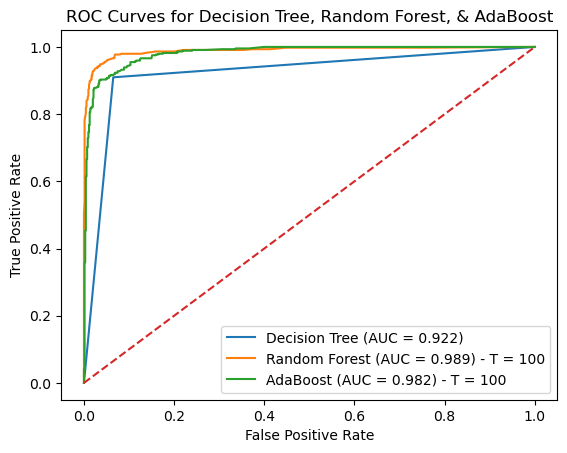

In [7]:
'''
    Part 3
    Plot the ROC curves for the decision tree model, Random Forest with 100 trees, and AdaBoost with 100 trees.
'''

# train decison tree, Random Forest, and Adaboost
decision_tree = DecisionTreeClassifier(random_state = 5)
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 5)
adaboost = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 1), n_estimators = 100, random_state = 5)

decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
adaboost.fit(X_train, y_train)

# get probabilities for the curves
decision_tree_prob = decision_tree.predict_proba(X_test)[:, 1]
random_forest_prob = random_forest.predict_proba(X_test)[:, 1]
adaboost_prob = adaboost.predict_proba(X_test)[:, 1]

# compute ROC curves
decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test, decision_tree_prob)
random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_prob)
adaboost_fpr, adaboost_tpr, _ = roc_curve(y_test, adaboost_prob)

# compute AUC
decision_tree_auc = auc(decision_tree_fpr, decision_tree_tpr)
random_forest_auc = auc(random_forest_fpr, random_forest_tpr)
adaboost_auc = auc(adaboost_fpr, adaboost_tpr)

# plot the ROC curves
plt.plot(decision_tree_fpr, decison_tree_tpr, label = f"Decision Tree (AUC = {round(decision_tree_auc, 3)})")
plt.plot(random_forest_fpr, random_forest_tpr, label = f"Random Forest (AUC = {round(random_forest_auc, 3)}) - T = 100")
plt.plot(adaboost_fpr, adaboost_tpr, label = f"AdaBoost (AUC = {round(adaboost_auc, 3)}) - T = 100")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Decision Tree, Random Forest, & AdaBoost")
plt.legend()
plt.show()